In [41]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [42]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # in colab cuda works
print(device)

cuda


In [43]:
train_transform = T.Compose([
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

test_transform = T.Compose([
    T.ToTensor(),
    T.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

In [44]:
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
testset  = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)

train_loader = DataLoader(trainset, batch_size=256, shuffle=True, num_workers=2)
test_loader  = DataLoader(testset, batch_size=256, num_workers=2)

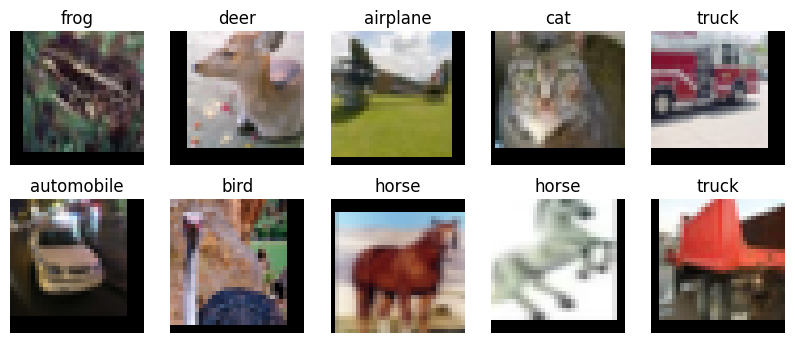

In [45]:
#Visualize input images
classes = trainset.classes

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2,5,figsize=(10,4))

for i, ax in enumerate(axes.flatten()):
    img = images[i].permute(1,2,0)
    img = img * 0.5 + 0.5
    ax.imshow(img)
    ax.set_title(classes[labels[i]])
    ax.axis('off')

plt.show()

In [46]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Channels grow: 3 → 64 → 128 → 256 → 512
        self.conv1 = nn.Conv2d(3,64,3,padding=1)
        self.bn1   = nn.BatchNorm2d(64)
        self.conv2 = nn.Conv2d(64,128,3,padding=1)
        self.bn2   = nn.BatchNorm2d(128)
        self.conv3 = nn.Conv2d(128,256,3,padding=1)
        self.bn3   = nn.BatchNorm2d(256)
        self.conv4 = nn.Conv2d(256,512,3,padding=1)
        self.bn4   = nn.BatchNorm2d(512)
        self.pool = nn.MaxPool2d(2,2)
        # Correct size after 4 pools: 32 → 16 → 8 → 4 → 2
        self.fc1 = nn.Linear(2*2*512,256)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256,10)

    def forward(self,x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = self.pool(F.relu(self.bn4(self.conv4(x))))
        x = x.view(x.size(0),-1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [47]:
model = CNN().to(device)
lossfun = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0007)

In [48]:
epochs = 15
train_losses = []
train_accs = []
test_losses = []
test_accs = []

for epoch in range(epochs):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for X,y in train_loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        yHat = model(X)
        loss = lossfun(yHat,y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        _,pred = torch.max(yHat,1)
        correct += (pred==y).sum().item()
        total += y.size(0)
    train_losses.append(total_loss/len(train_loader))
    train_accs.append(100*correct/total)
    print(f"Epoch {epoch+1} | Loss: {train_losses[-1]:.4f} | Acc: {train_accs[-1]:.2f}%")

Epoch 1 | Loss: 1.5436 | Acc: 43.20%
Epoch 2 | Loss: 1.1172 | Acc: 60.53%
Epoch 3 | Loss: 0.9668 | Acc: 66.16%
Epoch 4 | Loss: 0.8612 | Acc: 70.24%
Epoch 5 | Loss: 0.7922 | Acc: 72.75%
Epoch 6 | Loss: 0.7405 | Acc: 74.60%
Epoch 7 | Loss: 0.7007 | Acc: 76.07%
Epoch 8 | Loss: 0.6596 | Acc: 77.52%
Epoch 9 | Loss: 0.6393 | Acc: 78.46%
Epoch 10 | Loss: 0.6048 | Acc: 79.74%
Epoch 11 | Loss: 0.5793 | Acc: 80.57%
Epoch 12 | Loss: 0.5558 | Acc: 81.14%
Epoch 13 | Loss: 0.5337 | Acc: 82.16%
Epoch 14 | Loss: 0.5148 | Acc: 82.70%
Epoch 15 | Loss: 0.4930 | Acc: 83.36%


In [49]:
model.eval()
test_loss = 0
correct = 0
total = 0

with torch.no_grad():
    for X,y in test_loader:
        X, y = X.to(device), y.to(device)
        yHat = model(X)
        loss = lossfun(yHat,y)
        test_loss += loss.item()
        _,pred = torch.max(yHat,1)
        correct += (pred==y).sum().item()
        total += y.size(0)

test_losses.append(test_loss / len(test_loader))
test_accs.append(100 * correct / total)

## PLOT LOSS AND ACCURACY

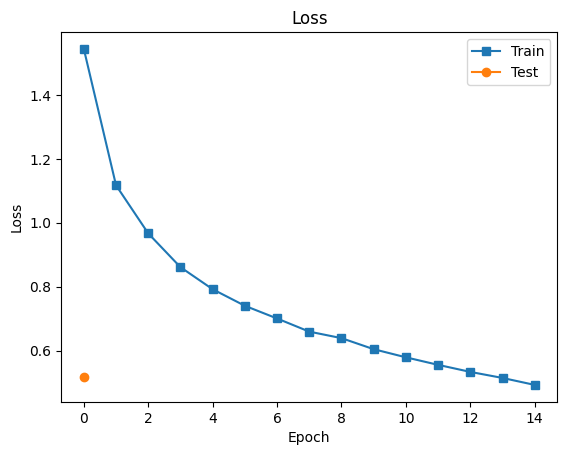

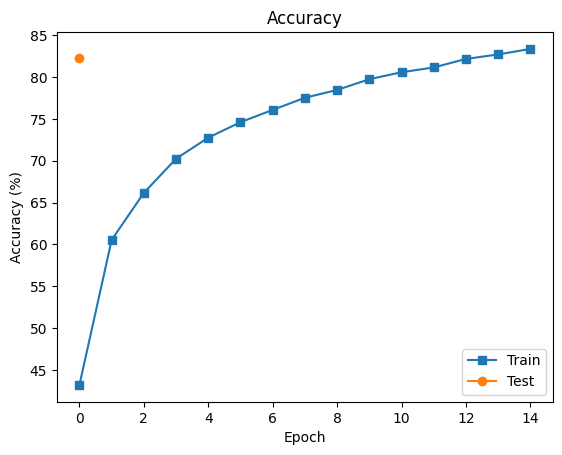

In [50]:
plt.figure()
plt.plot(train_losses, 's-', label='Train')
plt.plot(test_losses, 'o-', label='Test')
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.figure()
plt.plot(train_accs, 's-', label='Train')
plt.plot(test_accs, 'o-', label='Test')
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()

plt.show()